In [13]:
import polars as pl
from sklearn.cluster import KMeans
import numpy as np

In [47]:
df_rust = pl.read_csv('../data/characteristics.csv', has_header=True, truncate_ragged_lines=True, separator=';')
df_rust = df_rust.with_columns(
    pl.col("Rust percentage")
    .cast(pl.Utf8)
    .str.replace(",", ".")
    .cast(pl.Float64)
    / 100
)

In [134]:
def group(name, group_names, df, n_clusters=3, log=True, base=1, percentage=False):
    kmeans = KMeans(n_clusters, random_state=42)
    values = df.get_column(name).cast(pl.Float64).to_numpy()
    valid_mask = np.isfinite(values)

    groups = np.full(len(values), None, dtype=object)

    if log:
        valid_values = np.log(values[valid_mask]).reshape(-1, 1)
    else:
        valid_values = values[valid_mask].reshape(-1, 1)
    groups[valid_mask] = kmeans.fit_predict(valid_values)
    df = df.with_columns(pl.Series(f"{name}_group", groups))

    order = np.argsort(kmeans.cluster_centers_.ravel())
    remap = {old: new for new, old in enumerate(order)}

    groups = np.array([remap[g] if g is not None else None for g in groups], dtype=object)
    kmeans.cluster_centers_ = kmeans.cluster_centers_[order]

    df = df.with_columns(pl.Series(f"{name}_group", groups))

    stars = df.get_column(name).cast(pl.Float64).to_numpy()
    valid = np.isfinite(stars)
    stats_order = np.argsort(kmeans.cluster_centers_.ravel())
    line = f"  [{name}], "
    for new_idx, old_idx in enumerate(stats_order):
        mask = (groups == old_idx) & valid
        group_stars = stars[mask]
        if log:
            center = float(np.exp(kmeans.cluster_centers_[old_idx, 0]))
        else:
            center = float(kmeans.cluster_centers_[old_idx, 0])

        if group_stars.size:
            def _fmt_num(v):
                v *= base
                full = f"{float(v):.2f}"
                sci = f"{float(v):.1e}"
                mantissa, exp = sci.split("e")
                sci = f"{mantissa} times 10^{int(exp)+1:d}"
                return sci if len(full) > 8 else full

            line += f"[${group_stars.size}$], [${_fmt_num(group_stars.min())}{'%' if percentage else ''}$], [${_fmt_num(group_stars.max())}{'%' if percentage else ''}$], [${_fmt_num(center)}{'%' if percentage else ''}$], "
    print(line)

    for item in df.iter_rows(named=True):
        group = group_names[item[f"{name}_group"]] if item[f"{name}_group"] is not None else None
        if group is not None:
            print(f"{group}")
        else:
            print()

In [88]:
def plot(name, df):
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(10, 6))
    sns.histplot(df.get_column(name).cast(pl.Float64).to_numpy(), bins=30, kde=True)
    plt.title(f"Distribution of {name}")
    plt.xlabel(name)
    plt.ylabel("Frequency")
    plt.show()

In [120]:
group("Stars", ["Low", "Medium", "High"], df_rust)

  [Stars], [$139$], [$305$], [$1061$], [$548$], [$92$], [$1091$], [$6120$], [$2145$], [$54$], [$6283$], [$1.1 times 10^6$], [$1.8 times 10^5$], 
Low
Medium
Low
Medium
Low
Low
Low
Low
Medium
Low
Medium
Medium
Low
Low
Low
High
Medium
High
Medium
Medium
Medium
Low
Low
Medium
Medium
Medium
High
Low
Low
Low
Low
Low
Medium
Medium
Low
Low
Medium
Low
Low
Medium
Low
High
Medium
High
Low
Medium
High
Low
Low
Medium
Low
Low
Low
High
Medium
High
Low
High
Low
Medium
High
Low
Low
Medium
Low
Low
Low
Low
Low
Low
Low
High
Low
Low
Low
Low
High
Low
Low
Low
High
Low
Low
Medium
High
Medium
High
Low
Low
Medium
Medium
Medium
Low
Low
Medium
Low
Low
Medium
Medium
Medium
High
High
Low
High
Low
Low
Low
High
High
Low
Low
Medium
High
Low
High
Low
Low
Low
Medium
Medium
Low
Medium
Low
High
Low
Low
Medium
Medium
Low
Low
Medium
Low
Low
Medium
Low
Low
High
Medium
Medium
Medium
Low
Low
Low
Low
Medium
Low
High
Medium
High
Medium
Low
Low
Low
Medium
High
Low
Medium
Low
Medium
High
Low
Low
Medium
Low
Medium
Low
Medium
Medium

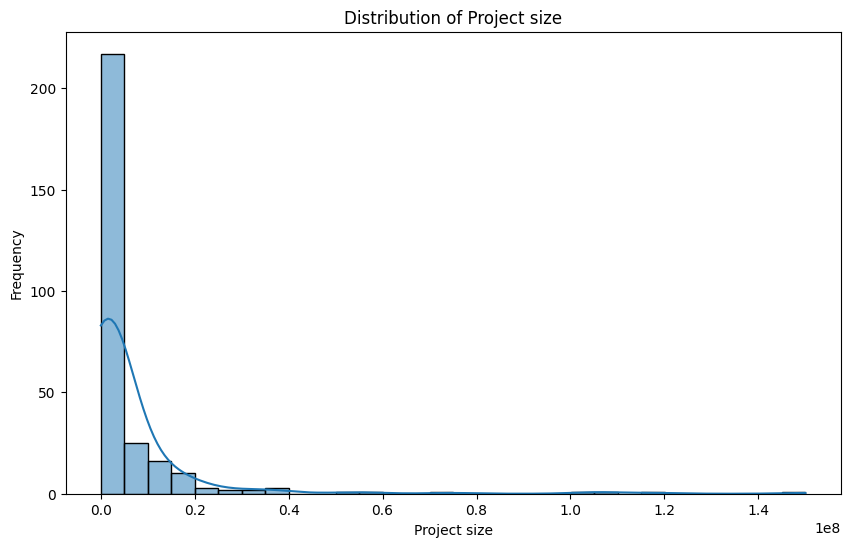

In [90]:
plot("Project size", df_rust)

In [121]:
group("Original stars", ["Low", "Medium", "High"], df_rust)

  [Original stars], [$9$], [$5$], [$529$], [$143$], [$43$], [$677$], [$7415$], [$2583$], [$41$], [$8561$], [$2.1 times 10^6$], [$2.5 times 10^5$], 
Medium




Medium
Medium






High

High





High



Medium

Medium
Medium
Medium

Medium
High







Medium
Medium
Low





Medium






High


Medium







Medium



Medium

High








High



High

High





Medium





High





Medium
High


Medium

High



Medium
High



Medium
High
Medium


High

High
Medium
Low

Medium










High

High
Low




Low

Medium





High
Medium



High




High

High
High

High

Medium




Medium
Medium
High

Medium

Low
Medium



Medium



High

Medium

Low
High


High












Medium

High


Medium





Medium

Medium
Medium




High
Low



High

High
High





Medium







Medium
High

High




High
High

Medium



Medium
Low
Medium
High
High

Low
High
High

Medium
Medium



In [122]:
group("Forks", ["Low", "Medium", "High"], df_rust)

  [Forks], [$81$], [$4$], [$58$], [$29$], [$139$], [$59$], [$364$], [$118$], [$65$], [$425$], [$1.7 times 10^5$], [$1453$], 
Low
High
Low
Medium
Medium
Medium
Low
Medium
Medium
Medium
Medium
Medium
Medium
Low
Low
High
Low
High
Medium
Medium
Medium
Low
Low
Medium
Medium
Medium
High
Low
Low
Low
Medium
Low
High
Medium
Low
Medium
High
Low
Medium
Medium
Low
High
Medium
High
Low
Medium
High
Low
Low
Medium
Medium
Medium
Low
Medium
Medium
High
Medium
High
Medium
High
High
Medium
Low
Medium
Medium
Medium
Medium
Medium
Medium
Low
Medium
High
Medium
Low
Medium
Low
High
Medium
Medium
Medium
High
Low
Medium
Medium
High
High
High
Medium
Medium
Medium
Medium
Medium
Low
Low
Medium
Medium
Low
High
Low
Medium
High
High
Medium
High
Medium
Medium
Low
High
High
Medium
Medium
Medium
Medium
Low
High
Low
Low
Medium
Medium
High
Low
Medium
Low
High
Low
Medium
Medium
Low
Low
Medium
High
Low
Medium
Medium
Low
Medium
High
Low
Medium
Medium
Medium
Low
Low
Low
Low
Medium
High
Medium
High
Medium
Medium
Medium
Low
Med

In [ ]:
group("Original forks", ["Low", "Medium", "High"], df_rust)

  [Original forks], [$18$], [$5$], [$166$], [$58$], [$55$], [$210$], [$2312$], [$719$], [$20$], [$2562$], [$3.4 times 10^5$], [$7571$], 
High




Low
Medium






Medium

High





Medium



Medium

Medium
Low
Low

Medium
High







Medium
Medium
Low





Medium






Medium


Medium







Medium



Medium

Medium








High



Medium

High





Low





Medium





Medium
High


Medium

Medium



Medium
High



Medium
High
Medium


Medium

High
Medium
Low

Medium










Medium

Medium
Medium




Low

Low





Medium
Medium



High




Medium

High
Medium

Medium

Medium




Low
Low
High

Medium

Low
Medium



Low



High

Low

Low
Medium


High












Medium

High


Medium





Medium

Medium
Medium




High
Low



High

Medium
Medium





Medium







Medium
Medium

Medium




Medium
Medium

Medium



Medium
Low
Low
High
High

Low
High
Medium

Medium
Medium



In [135]:
group("Project size", ["Small", "Medium", "Large"], df_rust, base=0.00001)

  [Project size], [$89$], [$0.11$], [$5.15$], [$1.87$], [$124$], [$5.26$], [$43.05$], [$14.50$], [$72$], [$44.93$], [$1500.24$], [$135.89$], 
Medium
Medium
Medium
Medium
Small
Large
Small
Medium
Medium
Medium
Large
Small
Medium
Medium
Small
Large
Medium
Medium
Large
Medium
Small
Medium
Small
Medium
Small
Medium
Large
Small
Small
Small
Large
Medium
Large
Large
Small
Small
Large
Small
Large
Small
Small
Medium
Medium
Large
Medium
Medium
Small
Small
Small
Small
Medium
Medium
Small
Small
Small
Large
Medium
Large
Small
Large
Large
Medium
Medium
Small
Large
Medium
Large
Medium
Medium
Medium
Small
Large
Medium
Small
Medium
Large
Medium
Medium
Small
Small
Large
Medium
Medium
Medium
Large
Medium
Large
Small
Large
Medium
Medium
Large
Small
Small
Small
Small
Large
Large
Medium
Large
Large
Large
Medium
Large
Medium
Small
Small
Large
Small
Medium
Medium
Small
Medium
Medium
Large
Large
Medium
Small
Small
Large
Small
Medium
Medium
Large
Small
Small
Medium
Medium
Small
Medium
Medium
Small
Small
Medium


In [136]:
group("Original project size", ["Small", "Medium", "Large"], df_rust, base=0.00001)

  [Original project size], [$34$], [$0.18$], [$4.33$], [$1.46$], [$22$], [$4.96$], [$43.40$], [$14.73$], [$36$], [$46.96$], [$2838.52$], [$146.63$], 
Medium




Large
Small






Medium

Large





Large



Large

Small
Small
Small

Large
Large







Small
Medium
Small





Small






Large


Small







Large



Medium

Large








Large



Large

Medium





Small





Large





Small
Large


Large

Small



Large
Small



Small
Large
Large


Medium

Medium
Small
Small

Small










Small

Medium
Medium




Small

Small





Large
Medium



Large




Medium

Large
Medium

Large

Small




Small
Large
Large

Medium

Large
Medium



Small



Medium

Small

Small
Small


Large












Small

Medium


Medium





Medium

Small
Large




Large
Small



Small

Medium
Large





Small







Medium
Small

Small




Large
Large

Large



Large

Small
Large
Large

Small
Large
Medium

Medium
Large



In [126]:
group("Rust percentage", ["Low", "Medium", "High"], df_rust, log=False, percentage=True)

  [Rust percentage], [$64$], [$4%$], [$39%$], [$21%$], [$74$], [$41%$], [$78%$], [$61%$], [$147$], [$79%$], [$100%$], [$95%$], 
High
Low
Medium
Low
Medium
Low
High
Low
Medium
Low
Low
Medium
Medium
High
High
High
Medium
Low
High
Medium
High
High
Medium
Low
High
High
Medium
High
Medium
High
Low
High
High
Medium
High
Low
Low
High
Medium
High
High
Medium
High
Medium
Medium
High
High
High
High
Medium
Low
Medium
Medium
High
Medium
High
High
Medium
High
High
Medium
High
High
Medium
Low
Low
High
High
Medium
Low
Medium
Low
High
High
High
Low
Low
Low
Low
High
Medium
High
Low
High
Low
High
Medium
High
Low
Medium
High
High
High
High
Medium
High
High
Medium
Medium
Medium
Low
Medium
Medium
Medium
High
High
Medium
Low
Medium
High
Medium
High
High
High
Low
High
Medium
High
Medium
Medium
High
High
High
Low
High
High
High
High
High
High
Low
High
High
Medium
High
Low
High
High
Low
Medium
Medium
Medium
High
High
High
High
Medium
High
Medium
Medium
High
High
High
Low
Medium
Medium
High
High
High
Low
Low
Me

<>:91: SyntaxWarning: invalid escape sequence '\m'
<>:93: SyntaxWarning: invalid escape sequence '\m'
<>:91: SyntaxWarning: invalid escape sequence '\m'
<>:93: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_979702/121619771.py:91: SyntaxWarning: invalid escape sequence '\m'
  mean_line = Line2D([0], [0], color='black', linewidth=2, label='Mean ($\mu$)')
/tmp/ipykernel_979702/121619771.py:93: SyntaxWarning: invalid escape sequence '\m'
  labels.append('Mean ($\mu$)')


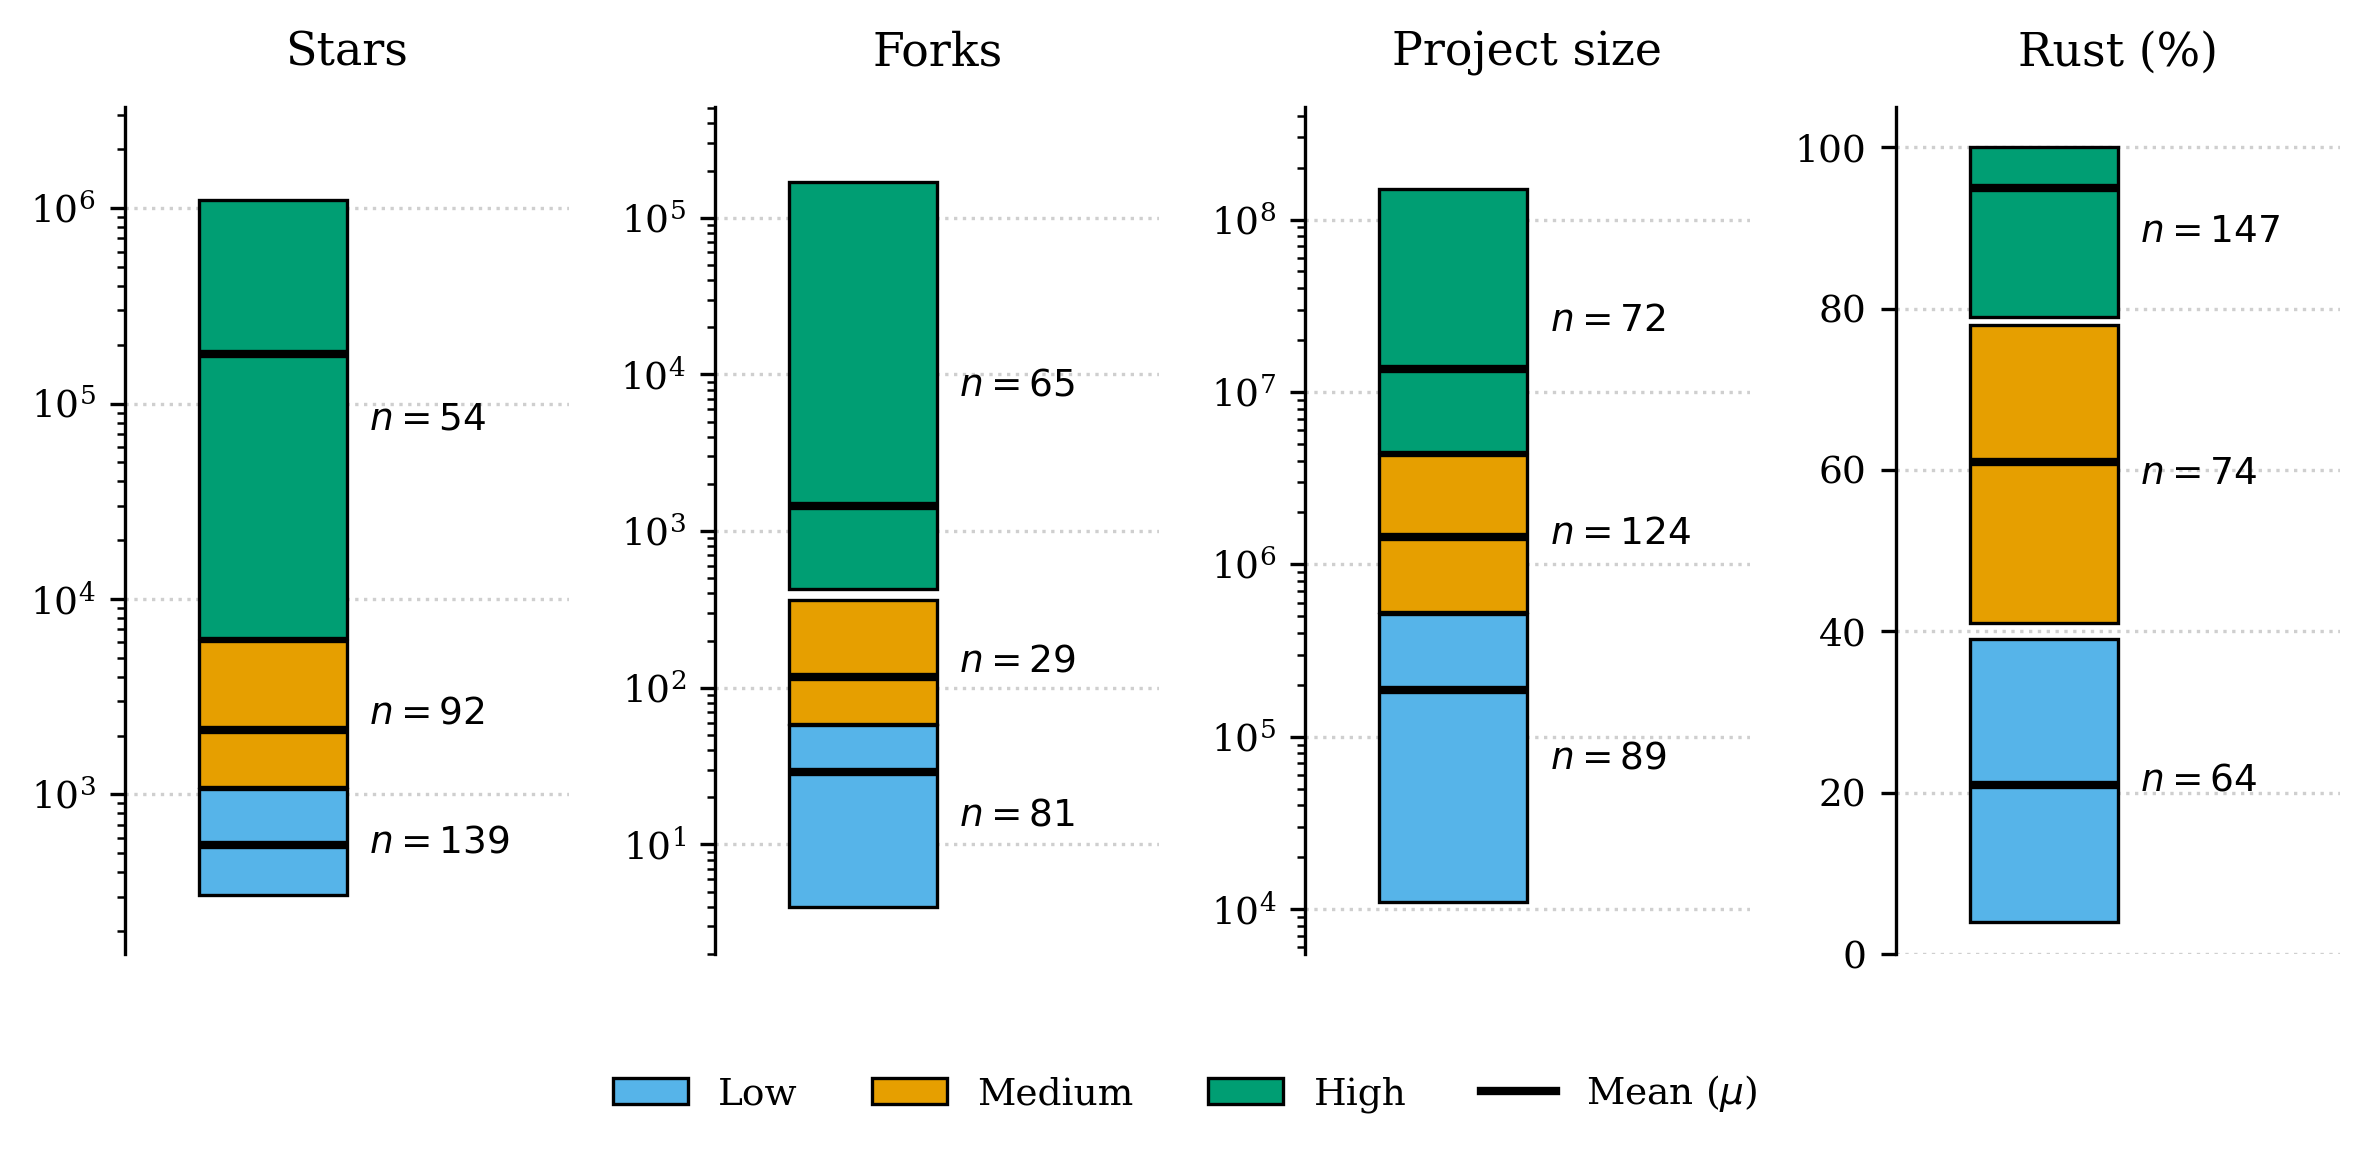

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker

data = {
    'Stars': {
        'Low': {'n': 139, 'min': 305, 'max': 1061, 'mu': 548},
        'Medium': {'n': 92, 'min': 1091, 'max': 6120, 'mu': 2145},
        'High': {'n': 54, 'min': 6283, 'max': 1100000, 'mu': 180000}
    },
    'Forks': {
        'Low': {'n': 81, 'min': 4, 'max': 58, 'mu': 29},
        'Medium': {'n': 29, 'min': 59, 'max': 364, 'mu': 118},
        'High': {'n': 65, 'min': 425, 'max': 170000, 'mu': 1453}
    },
    'Project size': {
        'Low': {'n': 89, 'min': 0.11 * 10**5, 'max': 5.15 * 10**5, 'mu': 1.87 * 10**5},
        'Medium': {'n': 124, 'min': 5.26 * 10**5, 'max': 43.05 * 10**5, 'mu': 14.50 * 10**5},
        'High': {'n': 72, 'min': 44.93 * 10**5, 'max': 1500.24 * 10**5, 'mu': 135.89 * 10**5}
    },
    'Rust (%)': {
        'Low': {'n': 64, 'min': 4, 'max': 39, 'mu': 21},
        'Medium': {'n': 74, 'min': 41, 'max': 78, 'mu': 61},
        'High': {'n': 147, 'min': 79, 'max': 100, 'mu': 95}
    }
}

colors = {
    'Low': '#56B4E9',    # Sky Blue
    'Medium': '#E69F00', # Orange
    'High': '#009E73'    # Bluish Green
}
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300
})

fig, axes = plt.subplots(1, 4, figsize=(8, 3.8))

for ax, (feature, groups) in zip(axes, data.items()):
    min_overall = groups['Low']['min']
    max_overall = groups['High']['max']
    
    use_log = (max_overall / max(min_overall, 0.01) > 100) and feature != 'Rust (%)'
    
    if use_log:
        ax.set_yscale('log')

    ax.grid(axis='y', linestyle=':', alpha=0.6, zorder=0)

    for group_name, stats in groups.items():
        y_min = stats['min']
        y_max = stats['max']
        mu = stats['mu']
        n = stats['n']

        ax.bar(0, height=y_max - y_min, bottom=y_min, width=0.4,
               color=colors[group_name], edgecolor='black', linewidth=0.8, 
               label=group_name, zorder=3)

        ax.hlines(y=mu, xmin=-0.2, xmax=0.2, color='black', linewidth=2, zorder=5)

        if use_log:
            y_text = 10 ** ((np.log10(y_min) + np.log10(y_max)) / 2)
        else:
            y_text = (y_min + y_max) / 2

        ax.text(0.26, y_text, f'$n={n}$', ha='left', va='center',
                color='black', fontsize=9, zorder=5)

    ax.set_title(feature, pad=10)
    ax.set_xticks([]) 
    ax.set_xlim(-0.4, 0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    if use_log:
        ax.set_ylim(min_overall * 0.5, max_overall * 3)
        ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=6))
    else:
        ax.set_ylim(0, 105)

handles, labels = axes[0].get_legend_handles_labels()
mean_line = Line2D([0], [0], color='black', linewidth=2, label='Mean ($\mu$)')
handles.append(mean_line)
labels.append('Mean ($\mu$)')

fig.legend(handles, labels, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

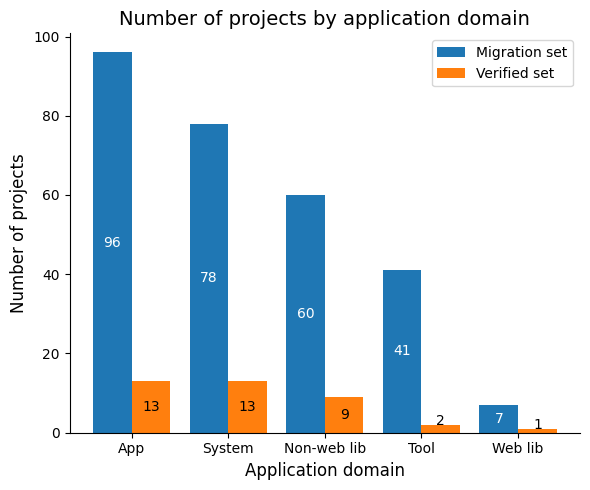

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the prompt (excluding Grand Total)
labels = ['App', 'System', 'Non-web lib', 'Tool', 'Web lib']
col1 = [96, 78, 60, 41, 7]
col2 = [13, 13, 9, 2, 1]

x = np.arange(len(labels))  # the label locations
width = 0.4  # the width of the bars

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 5))

# Plot the columns side-by-side
bars1 = ax.bar(x - width/2, col1, width, color='#1f77b4', label='Migration set')
bars2 = ax.bar(x + width/2, col2, width, color='#ff7f0e', label='Verified set')

# Add labels, title, and legend
ax.set_ylabel('Number of projects', fontsize=12)
ax.set_xlabel('Application domain', fontsize=12)
ax.set_title('Number of projects by application domain', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add numerical annotations inside the bars for readability
for bar in bars1:
    yval = bar.get_height()
    # If the bar is short, place text slightly above it to avoid overlapping the bottom axis
    y_pos = yval / 2 if yval > 5 else yval + 1
    color = 'white' if yval > 5 else 'black'
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, int(yval), 
            ha='center', va='center', color=color, fontsize=10)

for bar in bars2:
    yval = bar.get_height()
    y_pos = yval / 2 if yval > 5 else yval + 1
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, int(yval), 
            ha='center', va='center', color='black', fontsize=10)

# Clean up layout
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

# Save the plot
plt.savefig('grouped_bar_chart.png')

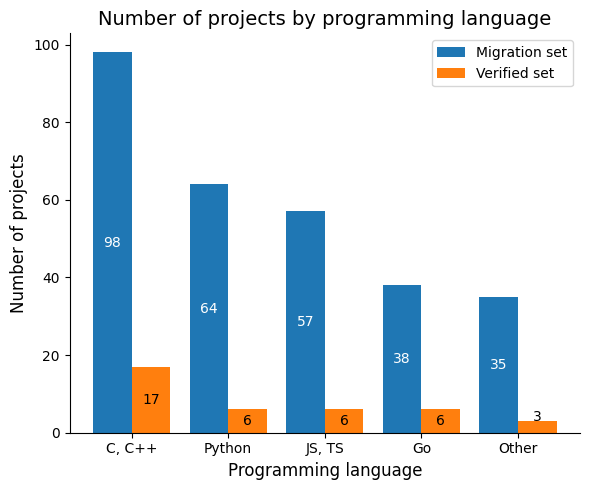

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# New Data
labels = ['C, C++', 'Python', 'JS, TS', 'Go', 'Other']
col1 = [98, 64, 57, 38, 35]
col2 = [17, 6, 6, 6, 3]

x = np.arange(len(labels))  # the label locations
width = 0.4  # the width of the bars

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 5))

# Plot the columns side-by-side
bars1 = ax.bar(x - width/2, col1, width, color='#1f77b4', label='Migration set')
bars2 = ax.bar(x + width/2, col2, width, color='#ff7f0e', label='Verified set')

# Add labels, title, and legend
ax.set_ylabel('Number of projects', fontsize=12)
ax.set_xlabel('Programming language', fontsize=12)
ax.set_title('Number of projects by programming language', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add numerical annotations inside the bars for readability
for bar in bars1:
    yval = bar.get_height()
    # Adjust position/color for very short bars to ensure readability
    y_pos = yval / 2 if yval > 5 else yval + 1
    color = 'white' if yval > 5 else 'black'
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, int(yval), 
            ha='center', va='center', color=color, fontsize=10)

for bar in bars2:
    yval = bar.get_height()
    y_pos = yval / 2 if yval > 5 else yval + 1
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, int(yval), 
            ha='center', va='center', color='black', fontsize=10)

# Clean up layout
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

# Display and save
plt.show()

In [8]:
import polars as pl

df = pl.read_csv('../data/verified_characteristics.csv', has_header=True, truncate_ragged_lines=True, separator=';')

desired = ["Project", "Original project", "Original languages", "Domain", "Stars", "Forks", "Size", "Rust percentage"]
df = df.select([pl.col(c) for c in desired]).sort("Project")

for item in df.iter_rows(named=True):
    original = item['Original project'] if item['Original project'] else ""
    print(f"    table.cell(align: left)[{item['Project']}], table.cell(align: left)[{original}], table.cell(align: left)[{item['Original languages']}], table.cell(align: left)[{item['Domain']}], [{item['Stars']}], [{item['Forks']}], [{item['Size']}], [{item['Rust percentage'].replace(',', '.')}], ")

    table.cell(align: left)[BitBoxSwiss/bitbox02-firmware], table.cell(align: left)[], table.cell(align: left)[C], table.cell(align: left)[System], [349], [127], [8025432], [26.7], 
    table.cell(align: left)[KiwiTalk/KiwiTalk], table.cell(align: left)[], table.cell(align: left)[TypeScript], table.cell(align: left)[App], [738], [90], [414612], [49.9], 
    table.cell(align: left)[NixOS/nixos-search], table.cell(align: left)[], table.cell(align: left)[Python], table.cell(align: left)[App], [538], [150], [302594], [31.9], 
    table.cell(align: left)[OISF/suricata], table.cell(align: left)[], table.cell(align: left)[C], table.cell(align: left)[System], [6116], [1678], [19570385], [24.0], 
    table.cell(align: left)[SeaDve/Kooha], table.cell(align: left)[], table.cell(align: left)[Python], table.cell(align: left)[App], [3317], [93], [218788], [96.2], 
    table.cell(align: left)[amir20/dtop], table.cell(align: left)[], table.cell(align: left)[Go], table.cell(align: left)[App], [1008], [